# Phase 4 — Model Training: Student Dropout Prediction

In this phase, we train machine learning models to predict whether a student is likely to drop out of college.

Using the preprocessed dataset generated in Phase 3, we will train multiple classification models and evaluate their performance using several metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The goal is to identify the model that best predicts student dropout risk while maintaining a balance between correctly identifying at-risk students and minimizing incorrect predictions.

This phase includes:

• Loading the processed datasets  
• Training multiple machine learning models  
• Evaluating model performance  
• Comparing models  
• Selecting the best-performing model

In [33]:
import pandas as pd
import numpy as np

In [34]:
import joblib

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
from sklearn.metrics import roc_curve

In [37]:
from sklearn.model_selection import cross_val_score

In [63]:
from sklearn.model_selection import GridSearchCV

## Loading Processed Datasets

In Phase 3, the dataset was cleaned, scaled, and balanced using SMOTE.  
The processed datasets were saved to disk to create a modular and reproducible machine learning pipeline.

Instead of repeating preprocessing steps in every notebook, we load the prepared datasets directly. This mirrors real-world machine learning workflows where preprocessing and model training are often separated.

The datasets loaded here include:

• `X_train_smote` — Training features after scaling and SMOTE balancing  
• `y_train_smote` — Balanced training target labels  
• `X_test_scaled` — Scaled test features  
• `y_test` — Original test labels

Using these datasets ensures the model is trained on balanced data while evaluation is performed on the original distribution.

In [38]:
# Load processed datasets
X_train = pd.read_csv("../data/processed/X_train_smote.csv")
y_train = pd.read_csv("../data/processed/y_train_smote.csv")
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [39]:
# Convert target DataFrames to 1D arrays
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Verifying Dataset Shapes and Target Distribution

Before training models, it is important to confirm that the datasets were loaded correctly.

We check:

• The shapes of training and testing datasets  
• The number of features used for prediction  
• The distribution of the target variable

The training data should appear balanced due to SMOTE, while the test data should maintain the original class distribution. This ensures the model is evaluated under realistic conditions.

In [40]:
# Check dataset shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4804, 36)
y_train shape: (4804,)
X_test shape: (885, 36)
y_test shape: (885,)


In [41]:
# Preview target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training target distribution:
Dropout_Binary
1    2402
0    2402
Name: count, dtype: int64

Testing target distribution:
Dropout_Binary
0    601
1    284
Name: count, dtype: int64


## Importing Machine Learning Models and Evaluation Metrics

To evaluate different modeling approaches, we import several classification algorithms from the Scikit-learn library.

The models used in this phase are:

• **Logistic Regression** — a linear baseline model commonly used for binary classification  
• **Decision Tree** — a non-linear model capable of learning complex feature relationships  
• **Random Forest** — an ensemble method that improves decision trees by combining multiple trees

We also import evaluation metrics such as Accuracy, Precision, Recall, F1 Score, ROC-AUC, and the Confusion Matrix to measure model performance.

In [42]:
# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [43]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Training the Baseline Model — Logistic Regression

Logistic Regression is used as the baseline model for this project.

Despite its name, Logistic Regression is a classification algorithm that estimates the probability that a data point belongs to a specific class. It is widely used because it is simple, interpretable, and often performs surprisingly well.

Training a baseline model allows us to establish a reference point for comparing more complex models later in the notebook.

In [44]:
# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [45]:
# Make predictions on test data
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

## Evaluating Logistic Regression Performance

After training the model, we evaluate its performance using multiple metrics.

Accuracy alone is not sufficient when dealing with imbalanced datasets. Therefore, we also analyze:

• **Precision** — how many predicted dropouts were actually correct  
• **Recall** — how many real dropouts the model successfully identified  
• **F1 Score** — a balance between precision and recall  
• **ROC-AUC** — the model's ability to distinguish between classes across thresholds

These metrics provide a more complete view of the model's predictive ability.

In [46]:
# Evaluate Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Performance:")
print(f"Accuracy : {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"F1 Score : {f1_log:.4f}")
print(f"ROC-AUC  : {roc_auc_log:.4f}")

Logistic Regression Performance:
Accuracy : 0.8701
Precision: 0.7789
Recall   : 0.8310
F1 Score : 0.8041
ROC-AUC  : 0.9259


In [47]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

Confusion Matrix:
[[534  67]
 [ 48 236]]


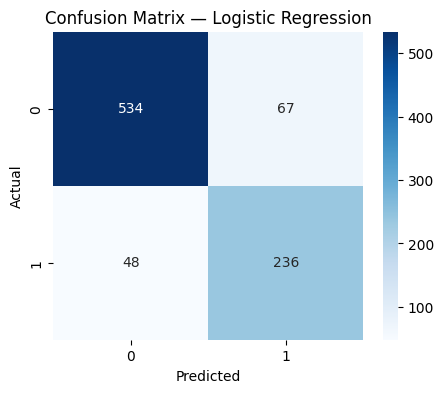

In [48]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Training a Decision Tree Model

Next, we train a Decision Tree classifier.

Decision Trees split the data into branches based on feature values, creating a tree-like structure of decisions. They can capture non-linear relationships between features and the target variable.

However, decision trees can sometimes overfit the training data, which makes it important to compare their performance with other models.

In [49]:
# Train Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [50]:
# Predictions for Decision Tree
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [51]:
# Evaluate Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Performance:")
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1 Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_tree:.4f}")

Decision Tree Performance:
Accuracy : 0.8011
Precision: 0.6875
Recall   : 0.6972
F1 Score : 0.6923
ROC-AUC  : 0.7737


In [52]:
# Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix:")
print(cm_tree)

Confusion Matrix:
[[511  90]
 [ 86 198]]


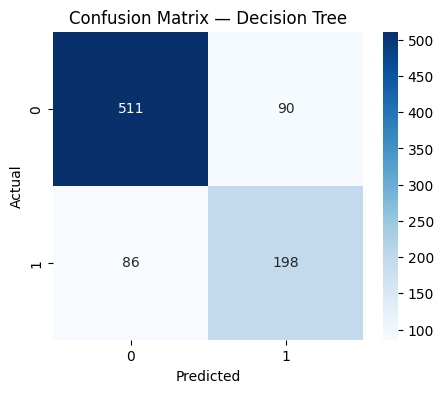

In [53]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Training a Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.

Instead of relying on a single tree, Random Forest averages the predictions of many trees, which reduces overfitting and improves generalization.

Because of this, Random Forest often performs better than individual decision trees and is commonly used in many real-world machine learning applications.

In [54]:
# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
# Predictions for Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [56]:
# Evaluate Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance:")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Performance:
Accuracy : 0.8836
Precision: 0.8415
Recall   : 0.7852
F1 Score : 0.8124
ROC-AUC  : 0.9318


In [57]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[559  42]
 [ 61 223]]


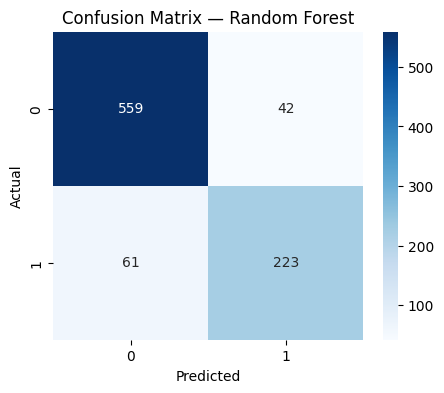

In [58]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve evaluates how well each model distinguishes between dropout and non-dropout students across different classification thresholds.

The ROC curve plots:

• True Positive Rate (Recall)  
• False Positive Rate  

A model with a curve closer to the **top-left corner** indicates stronger classification performance.

The **Area Under the Curve (ROC-AUC)** summarizes this performance into a single value, where higher values indicate better ability to separate classes.

Plotting ROC curves for multiple models on the same graph allows us to visually compare their classification performance.

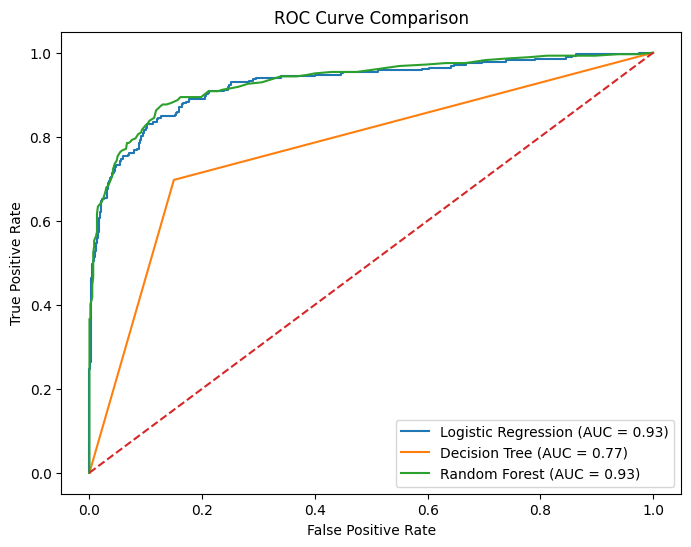

In [59]:
# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {roc_auc_tree:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

plt.plot([0,1], [0,1], linestyle='--')  # Random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

### Interpretation of ROC Curve Results

The ROC curve comparison shows that both Logistic Regression and Random Forest achieve strong classification performance with an AUC of approximately 0.93.

This indicates that the models can correctly distinguish between students who will drop out and those who will remain enrolled with high reliability.

The Decision Tree model performs noticeably worse, with an AUC of approximately 0.77. This suggests that the single decision tree is less effective at generalizing to unseen data.

Overall, Random Forest and Logistic Regression demonstrate the strongest predictive performance, with Random Forest offering slightly better overall classification metrics in earlier evaluations.

## 5-Fold Cross-Validation

While the train-test split provides an initial estimate of model performance, cross-validation gives a more reliable assessment of how well each model generalizes.

In 5-fold cross-validation, the training data is split into 5 subsets (folds). The model is trained on 4 folds and validated on the remaining fold. This process is repeated 5 times so that each fold is used once for validation.

This helps reduce the risk of relying too heavily on a single train-test split and provides a more stable estimate of model performance.

In this phase, we use cross-validation to compare the three models and check whether their results remain consistent across multiple data partitions.

In [60]:
# Perform 5-fold cross-validation using ROC-AUC
cv_log = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="roc_auc")
cv_tree = cross_val_score(tree_model, X_train, y_train, cv=5, scoring="roc_auc")
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="roc_auc")

print("Logistic Regression CV ROC-AUC Scores:", cv_log)
print("Mean ROC-AUC:", cv_log.mean())

print("\nDecision Tree CV ROC-AUC Scores:", cv_tree)
print("Mean ROC-AUC:", cv_tree.mean())

print("\nRandom Forest CV ROC-AUC Scores:", cv_rf)
print("Mean ROC-AUC:", cv_rf.mean())

Logistic Regression CV ROC-AUC Scores: [0.92136608 0.92188583 0.92095894 0.91475658 0.93157986]
Mean ROC-AUC: 0.9221094580157079

Decision Tree CV ROC-AUC Scores: [0.81587405 0.77425936 0.85432692 0.87417056 0.89791667]
Mean ROC-AUC: 0.8433095114345115

Random Forest CV ROC-AUC Scores: [0.93798727 0.94413548 0.96599316 0.97912985 0.99013238]
Mean ROC-AUC: 0.9634756267685954


### Cross-Validation Interpretation

The 5-fold cross-validation results provide a more reliable estimate of model performance by evaluating each model across multiple data splits.

Logistic Regression shows stable performance with a mean ROC-AUC of approximately 0.92, indicating strong predictive capability and consistent results across folds.

The Decision Tree model demonstrates lower performance and higher variability between folds, suggesting that it may be more sensitive to the training data and prone to overfitting.

The Random Forest model achieves the highest mean ROC-AUC of approximately 0.96, indicating excellent ability to distinguish between students who will drop out and those who will remain enrolled. The consistently high scores across folds confirm that Random Forest generalizes well to unseen data.

Based on these results, Random Forest remains the strongest candidate for the final model.

## Hyperparameter Tuning with GridSearchCV

Although the Random Forest model already performs strongly with default settings, its performance may be improved further by tuning its hyperparameters.

Hyperparameters are settings chosen before training the model, such as:

- the number of trees in the forest
- the maximum depth of each tree
- the minimum number of samples required to split a node

GridSearchCV systematically tests multiple combinations of these hyperparameters and uses cross-validation to identify the best-performing configuration.

In this phase, GridSearchCV is applied to the Random Forest model to find the optimal settings and produce the final tuned model.

In [64]:
# Define parameter grid for Random Forest tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [65]:
# GridSearchCV for Random Forest
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [66]:
# Best hyperparameters found by GridSearchCV
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [67]:
# Extract the best tuned model
best_model = grid_search.best_estimator_

print(best_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [68]:
# Predictions using the tuned Random Forest model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [69]:
# Evaluate tuned Random Forest model
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("Tuned Random Forest Performance:")
print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC-AUC  : {roc_auc_best:.4f}")

Tuned Random Forest Performance:
Accuracy : 0.8836
Precision: 0.8415
Recall   : 0.7852
F1 Score : 0.8124
ROC-AUC  : 0.9330


## Comparing Model Performance

After training multiple machine learning models and performing hyperparameter tuning, we compare their performance using several evaluation metrics.

The models evaluated in this phase include:

- Logistic Regression (baseline model)
- Decision Tree
- Random Forest with default parameters
- Random Forest after hyperparameter tuning using GridSearchCV

Creating a comparison table allows us to clearly observe how each model performs across key metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The evaluation metrics are displayed as percentages to improve readability and make it easier to compare model performance.

This comparison helps determine which model provides the most reliable predictions for identifying students at risk of dropping out.

In [ ]:
# Model comparison including tuned Random Forest

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (Default)",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_tree,
        accuracy_rf,
        accuracy_best
    ],
    "Precision": [
        precision_log,
        precision_tree,
        precision_rf,
        precision_best
    ],
    "Recall": [
        recall_log,
        recall_tree,
        recall_rf,
        recall_best
    ],
    "F1 Score": [
        f1_log,
        f1_tree,
        f1_rf,
        f1_best
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_best
    ]
})

# Convert to percentages for readability
model_results.iloc[:,1:] = model_results.iloc[:,1:] * 100
model_results = model_results.round(2)

for col in model_results.columns[1:]:
    model_results[col] = model_results[col].astype(str) + "%"

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,87.01%,77.89%,83.1%,80.41%,92.59%
1,Decision Tree,80.11%,68.75%,69.72%,69.23%,77.37%
2,Random Forest (Default),88.36%,84.15%,78.52%,81.24%,93.18%
3,Random Forest (Tuned),88.36%,84.15%,78.52%,81.24%,93.3%


## Selecting the Best Performing Model

After training multiple models and evaluating their performance using Accuracy, Precision, Recall, F1 Score, and ROC-AUC, the Random Forest model consistently demonstrated the strongest overall results.

To further improve the model, hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. This process systematically evaluated different combinations of parameters to identify the configuration that produced the best generalization performance.

The tuned Random Forest model maintained the highest overall performance and showed strong stability across cross-validation folds.

For these reasons, the **tuned Random Forest model** is selected as the final model for this phase and will be saved for future use in prediction and deployment.

## Saving the Trained Model

To make the trained model reusable, we save it to disk using the `joblib` library.

Saving the model allows it to be loaded later without retraining, which is essential for deploying the model in applications such as a Streamlit dashboard.

The best-performing model will be stored as:

`models/best_model.pkl`

In [71]:
# Save the best performing model
joblib.dump(best_model, "../models/best_model.pkl")

['../models/best_model.pkl']

## Phase 4 Summary

In this phase, multiple machine learning models were trained and evaluated to predict student dropout risk.

Three models were initially trained:

- Logistic Regression (baseline model)
- Decision Tree
- Random Forest

Each model was evaluated using several performance metrics including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Additional visualizations such as confusion matrices and ROC curves were used to better understand model behavior.

To ensure the models generalize well to unseen data, 5-fold cross-validation was performed. The results confirmed that the Random Forest model consistently achieved the strongest predictive performance.

Hyperparameter tuning was then applied using GridSearchCV to further optimize the Random Forest model. The tuned model maintained the best overall performance and demonstrated strong stability across validation folds.

Based on these results, the **tuned Random Forest model** was selected as the final model for this phase.

The trained model was saved using `joblib` as:

`models/best_model.pkl`

This saved model will be used in the next phase to support prediction and deployment.